In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import random
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INPUT_CSV = "/content/drive/MyDrive/Q3_Counting/traffic_counts_per_second.csv"
OUTPUT_DIR = Path("/content/drive/MyDrive/Q5_GA_Optimization")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Genetic algorithm settings
POP_SIZE = 40
N_GENERATIONS = 50
ELITE_SIZE = 4
TOURNAMENT_SIZE = 4
MUTATION_RATE = 0.25
CROSSOVER_RATE = 0.85

# Signal parameter bounds
GREEN_VERTICAL_BOUNDS = (10, 80)
GREEN_HORIZONTAL_BOUNDS = (10, 80)
YELLOW_BOUNDS = (2, 6)
ALL_RED_BOUNDS = (0, 3)
PHASE_ORDER_VALUES = [0, 1]  # 0 = vertical first, 1 = horizontal first

# Saturation / discharge flow per second during green
SERVICE_RATE = {
    "top": 1,
    "bottom": 1,
    "left": 1,
    "right": 1
}

BASELINE_CHROMOSOME = {
    "green_vertical": 30,
    "green_horizontal": 30,
    "yellow_time": 3,
    "all_red_time": 1,
    "phase_order_flag": 0
}

In [3]:
traffic_df = pd.read_csv(INPUT_CSV)

required_columns = {"second", "top", "bottom", "left", "right", "total"}
missing_columns = required_columns - set(traffic_df.columns)
if missing_columns:
    raise ValueError(f"Missing columns in CSV: {missing_columns}")

traffic_df = traffic_df.sort_values("second").reset_index(drop=True)

print("Traffic data loaded")
print("Rows:", len(traffic_df))
display(traffic_df.head())

Traffic data loaded
Rows: 832


,second,top,bottom,left,right,total
0,0,0,1,1,1,3
1,1,0,0,0,2,2
2,2,0,0,0,0,0
3,3,0,0,0,2,2
4,4,0,0,1,0,1


In [4]:
def create_random_chromosome():
    return {
        "green_vertical": random.randint(*GREEN_VERTICAL_BOUNDS),
        "green_horizontal": random.randint(*GREEN_HORIZONTAL_BOUNDS),
        "yellow_time": random.randint(*YELLOW_BOUNDS),
        "all_red_time": random.randint(*ALL_RED_BOUNDS),
        "phase_order_flag": random.choice(PHASE_ORDER_VALUES)
    }

def clip_chromosome(chromosome):
    chromosome["green_vertical"] = int(np.clip(chromosome["green_vertical"], *GREEN_VERTICAL_BOUNDS))
    chromosome["green_horizontal"] = int(np.clip(chromosome["green_horizontal"], *GREEN_HORIZONTAL_BOUNDS))
    chromosome["yellow_time"] = int(np.clip(chromosome["yellow_time"], *YELLOW_BOUNDS))
    chromosome["all_red_time"] = int(np.clip(chromosome["all_red_time"], *ALL_RED_BOUNDS))
    chromosome["phase_order_flag"] = int(chromosome["phase_order_flag"])
    chromosome["phase_order_flag"] = 1 if chromosome["phase_order_flag"] >= 1 else 0
    return chromosome

def chromosome_to_dict(chromosome):
    return {
        "green_vertical": chromosome["green_vertical"],
        "green_horizontal": chromosome["green_horizontal"],
        "yellow_time": chromosome["yellow_time"],
        "all_red_time": chromosome["all_red_time"],
        "phase_order_flag": chromosome["phase_order_flag"]
    }

In [5]:
def get_phase_sequence(phase_order_flag):
    if phase_order_flag == 0:
        return ["vertical_green", "vertical_yellow", "all_red_1", "horizontal_green", "horizontal_yellow", "all_red_2"]
    else:
        return ["horizontal_green", "horizontal_yellow", "all_red_1", "vertical_green", "vertical_yellow", "all_red_2"]

def get_phase_duration(phase_name, chromosome):
    if phase_name == "vertical_green":
        return chromosome["green_vertical"]
    elif phase_name == "horizontal_green":
        return chromosome["green_horizontal"]
    elif phase_name in ["vertical_yellow", "horizontal_yellow"]:
        return chromosome["yellow_time"]
    elif phase_name in ["all_red_1", "all_red_2"]:
        return chromosome["all_red_time"]
    else:
        raise ValueError(f"Unknown phase: {phase_name}")

def get_green_directions(phase_name):
    if phase_name == "vertical_green":
        return ["top", "bottom"]
    elif phase_name == "horizontal_green":
        return ["left", "right"]
    return []

def simulate_traffic_signal(traffic_df, chromosome, return_time_series=True):
    chromosome = clip_chromosome(chromosome.copy())

    phase_sequence = get_phase_sequence(chromosome["phase_order_flag"])
    phase_idx = 0
    phase_name = phase_sequence[phase_idx]
    phase_remaining = get_phase_duration(phase_name, chromosome)

    queues = {
        "top": 0,
        "bottom": 0,
        "left": 0,
        "right": 0
    }

    total_waiting_time = 0
    max_total_queue = 0

    per_direction_wait_accumulator = {
        "top": 0,
        "bottom": 0,
        "left": 0,
        "right": 0
    }

    simulation_rows = []

    for _, row in traffic_df.iterrows():
        current_second = int(row["second"])

        # Add incoming traffic
        queues["top"] += int(row["top"])
        queues["bottom"] += int(row["bottom"])
        queues["left"] += int(row["left"])
        queues["right"] += int(row["right"])

        # Serve queues during green
        green_directions = get_green_directions(phase_name)
        for direction in green_directions:
            departure = min(queues[direction], SERVICE_RATE[direction])
            queues[direction] -= departure

        # Waiting penalty after arrivals and departures
        current_total_queue = sum(queues.values())
        total_waiting_time += current_total_queue
        max_total_queue = max(max_total_queue, current_total_queue)

        for direction in queues:
            per_direction_wait_accumulator[direction] += queues[direction]

        if return_time_series:
            simulation_rows.append({
                "second": current_second,
                "phase": phase_name,
                "queue_top": queues["top"],
                "queue_bottom": queues["bottom"],
                "queue_left": queues["left"],
                "queue_right": queues["right"],
                "total_queue": current_total_queue,
                "arrivals_top": int(row["top"]),
                "arrivals_bottom": int(row["bottom"]),
                "arrivals_left": int(row["left"]),
                "arrivals_right": int(row["right"])
            })

        # Advance signal timer
        phase_remaining -= 1
        if phase_remaining <= 0:
            phase_idx = (phase_idx + 1) % len(phase_sequence)
            phase_name = phase_sequence[phase_idx]
            phase_remaining = get_phase_duration(phase_name, chromosome)

    per_direction_average_wait = {
        direction: per_direction_wait_accumulator[direction] / len(traffic_df)
        for direction in per_direction_wait_accumulator
    }

    direction_imbalance = np.std(list(per_direction_average_wait.values()))

    fitness = (
        total_waiting_time
        + 0.2 * max_total_queue
        + 0.1 * direction_imbalance
    )

    simulation_df = pd.DataFrame(simulation_rows) if return_time_series else None

    metrics = {
        "fitness": fitness,
        "total_waiting_time": total_waiting_time,
        "max_total_queue": max_total_queue,
        "direction_imbalance": direction_imbalance,
        "avg_queue_top": per_direction_average_wait["top"],
        "avg_queue_bottom": per_direction_average_wait["bottom"],
        "avg_queue_left": per_direction_average_wait["left"],
        "avg_queue_right": per_direction_average_wait["right"]
    }

    return metrics, simulation_df

In [6]:
baseline_metrics, baseline_sim_df = simulate_traffic_signal(
    traffic_df,
    BASELINE_CHROMOSOME,
    return_time_series=True
)

print("Baseline chromosome:")
print(BASELINE_CHROMOSOME)
print("\nBaseline metrics:")
print(baseline_metrics)

display(baseline_sim_df.head())

Baseline chromosome:
{'green_vertical': 30, 'green_horizontal': 30, 'yellow_time': 3, 'all_red_time': 1, 'phase_order_flag': 0}

Baseline metrics:
{'fitness': np.float64(82336.3437057782), 'total_waiting_time': 82308, 'max_total_queue': 131, 'direction_imbalance': np.float64(21.437057781954298), 'avg_queue_top': 20.688701923076923, 'avg_queue_bottom': 6.115384615384615, 'avg_queue_left': 11.37860576923077, 'avg_queue_right': 60.74519230769231}


,second,phase,queue_top,queue_bottom,queue_left,queue_right,total_queue,arrivals_top,arrivals_bottom,arrivals_left,arrivals_right
0,0,vertical_green,0,0,1,1,2,0,1,1,1
1,1,vertical_green,0,0,1,3,4,0,0,0,2
2,2,vertical_green,0,0,1,3,4,0,0,0,0
3,3,vertical_green,0,0,1,5,6,0,0,0,2
4,4,vertical_green,0,0,2,5,7,0,0,1,0


In [7]:
def tournament_selection(population, fitness_scores, tournament_size=4):
    indices = random.sample(range(len(population)), tournament_size)
    best_idx = min(indices, key=lambda i: fitness_scores[i])
    return population[best_idx].copy()

def crossover(parent1, parent2):
    child1 = parent1.copy()
    child2 = parent2.copy()

    if random.random() < CROSSOVER_RATE:
        for key in parent1.keys():
            if random.random() < 0.5:
                child1[key], child2[key] = child2[key], child1[key]

    return clip_chromosome(child1), clip_chromosome(child2)

def mutate(chromosome):
    child = chromosome.copy()

    if random.random() < MUTATION_RATE:
        child["green_vertical"] += random.randint(-8, 8)
    if random.random() < MUTATION_RATE:
        child["green_horizontal"] += random.randint(-8, 8)
    if random.random() < MUTATION_RATE:
        child["yellow_time"] += random.randint(-1, 1)
    if random.random() < MUTATION_RATE:
        child["all_red_time"] += random.randint(-1, 1)
    if random.random() < MUTATION_RATE:
        child["phase_order_flag"] = 1 - child["phase_order_flag"]

    return clip_chromosome(child)

In [8]:
def run_genetic_algorithm(traffic_df, pop_size=40, n_generations=50, elite_size=4):
    population = [create_random_chromosome() for _ in range(pop_size)]
    history_rows = []

    best_chromosome = None
    best_metrics = None
    best_fitness = float("inf")

    for generation in range(n_generations):
        fitness_scores = []
        metrics_list = []

        for chromosome in population:
            metrics, _ = simulate_traffic_signal(traffic_df, chromosome, return_time_series=False)
            fitness_scores.append(metrics["fitness"])
            metrics_list.append(metrics)

        generation_best_idx = int(np.argmin(fitness_scores))
        generation_best_chromosome = population[generation_best_idx].copy()
        generation_best_metrics = metrics_list[generation_best_idx].copy()
        generation_best_fitness = fitness_scores[generation_best_idx]

        if generation_best_fitness < best_fitness:
            best_fitness = generation_best_fitness
            best_chromosome = generation_best_chromosome.copy()
            best_metrics = generation_best_metrics.copy()

        history_rows.append({
            "generation": generation,
            "best_fitness": generation_best_fitness,
            "mean_fitness": float(np.mean(fitness_scores)),
            "best_total_waiting_time": generation_best_metrics["total_waiting_time"],
            "best_max_total_queue": generation_best_metrics["max_total_queue"],
            "best_direction_imbalance": generation_best_metrics["direction_imbalance"],
            "green_vertical": generation_best_chromosome["green_vertical"],
            "green_horizontal": generation_best_chromosome["green_horizontal"],
            "yellow_time": generation_best_chromosome["yellow_time"],
            "all_red_time": generation_best_chromosome["all_red_time"],
            "phase_order_flag": generation_best_chromosome["phase_order_flag"]
        })

        sorted_indices = np.argsort(fitness_scores)
        next_population = [population[i].copy() for i in sorted_indices[:elite_size]]

        while len(next_population) < pop_size:
            parent1 = tournament_selection(population, fitness_scores, tournament_size=TOURNAMENT_SIZE)
            parent2 = tournament_selection(population, fitness_scores, tournament_size=TOURNAMENT_SIZE)

            child1, child2 = crossover(parent1, parent2)
            child1 = mutate(child1)
            child2 = mutate(child2)

            next_population.append(child1)
            if len(next_population) < pop_size:
                next_population.append(child2)

        population = next_population

        if generation % 5 == 0 or generation == n_generations - 1:
            print(
                f"Generation {generation:02d} | "
                f"best_fitness={generation_best_fitness:.2f} | "
                f"mean_fitness={np.mean(fitness_scores):.2f}"
            )

    history_df = pd.DataFrame(history_rows)
    return best_chromosome, best_metrics, history_df

In [9]:
best_chromosome, best_metrics, ga_history_df = run_genetic_algorithm(
    traffic_df,
    pop_size=POP_SIZE,
    n_generations=N_GENERATIONS,
    elite_size=ELITE_SIZE
)

print("\nBest chromosome found:")
print(best_chromosome)

print("\nBest metrics:")
print(best_metrics)

display(ga_history_df.head())

Generation 00 | best_fitness=51288.87 | mean_fitness=116361.30
Generation 05 | best_fitness=50301.89 | mean_fitness=57478.07
Generation 10 | best_fitness=50301.89 | mean_fitness=56049.07
Generation 15 | best_fitness=50301.89 | mean_fitness=56079.48
Generation 20 | best_fitness=50301.89 | mean_fitness=58139.03
Generation 25 | best_fitness=50301.89 | mean_fitness=54693.07
Generation 30 | best_fitness=50301.89 | mean_fitness=56685.29
Generation 35 | best_fitness=50301.89 | mean_fitness=55299.59
Generation 40 | best_fitness=50301.89 | mean_fitness=57130.85
Generation 45 | best_fitness=50301.89 | mean_fitness=57409.74
Generation 49 | best_fitness=50301.89 | mean_fitness=56252.25

Best chromosome found:
{'green_vertical': 39, 'green_horizontal': 57, 'yellow_time': 2, 'all_red_time': 0, 'phase_order_flag': 1}

Best metrics:
{'fitness': np.float64(50301.888955074275), 'total_waiting_time': 50281, 'max_total_queue': 100, 'direction_imbalance': np.float64(8.889550742752851), 'avg_queue_top': 25.

,generation,best_fitness,mean_fitness,best_total_waiting_time,best_max_total_queue,best_direction_imbalance,green_vertical,green_horizontal,yellow_time,all_red_time,phase_order_flag
0,0,51288.870273,116361.297632,51269,95,8.702733,37,53,2,0,1
1,1,51288.870273,80496.407040,51269,95,8.702733,37,53,2,0,1
2,2,51288.870273,64839.508038,51269,95,8.702733,37,53,2,0,1
3,3,51288.870273,64173.633073,51269,95,8.702733,37,53,2,0,1
4,4,51288.870273,57405.799122,51269,95,8.702733,37,53,2,0,1


In [10]:
best_sim_metrics, best_sim_df = simulate_traffic_signal(
    traffic_df,
    best_chromosome,
    return_time_series=True
)

print("Best simulation metrics:")
print(best_sim_metrics)

display(best_sim_df.head())

Best simulation metrics:
{'fitness': np.float64(50301.888955074275), 'total_waiting_time': 50281, 'max_total_queue': 100, 'direction_imbalance': np.float64(8.889550742752851), 'avg_queue_top': 25.861778846153847, 'avg_queue_bottom': 8.185096153846153, 'avg_queue_left': 4.673076923076923, 'avg_queue_right': 21.713942307692307}


,second,phase,queue_top,queue_bottom,queue_left,queue_right,total_queue,arrivals_top,arrivals_bottom,arrivals_left,arrivals_right
0,0,horizontal_green,0,1,0,0,1,0,1,1,1
1,1,horizontal_green,0,1,0,1,2,0,0,0,2
2,2,horizontal_green,0,1,0,0,1,0,0,0,0
3,3,horizontal_green,0,1,0,1,2,0,0,0,2
4,4,horizontal_green,0,1,0,0,1,0,0,1,0


In [11]:
comparison_df = pd.DataFrame([
    {
        "Strategy": "Fixed timing baseline",
        "Total waiting time": baseline_metrics["total_waiting_time"],
        "Max total queue": baseline_metrics["max_total_queue"],
        "Direction imbalance": baseline_metrics["direction_imbalance"],
        "Avg queue top": baseline_metrics["avg_queue_top"],
        "Avg queue bottom": baseline_metrics["avg_queue_bottom"],
        "Avg queue left": baseline_metrics["avg_queue_left"],
        "Avg queue right": baseline_metrics["avg_queue_right"],
        "Fitness": baseline_metrics["fitness"]
    },
    {
        "Strategy": "GA optimized",
        "Total waiting time": best_sim_metrics["total_waiting_time"],
        "Max total queue": best_sim_metrics["max_total_queue"],
        "Direction imbalance": best_sim_metrics["direction_imbalance"],
        "Avg queue top": best_sim_metrics["avg_queue_top"],
        "Avg queue bottom": best_sim_metrics["avg_queue_bottom"],
        "Avg queue left": best_sim_metrics["avg_queue_left"],
        "Avg queue right": best_sim_metrics["avg_queue_right"],
        "Fitness": best_sim_metrics["fitness"]
    }
])

display(comparison_df)

comparison_df.to_csv(OUTPUT_DIR / "baseline_vs_ga_comparison.csv", index=False)
ga_history_df.to_csv(OUTPUT_DIR / "ga_history.csv", index=False)
best_sim_df.to_csv(OUTPUT_DIR / "best_simulation_timeseries.csv", index=False)
baseline_sim_df.to_csv(OUTPUT_DIR / "baseline_simulation_timeseries.csv", index=False)

,Strategy,Total waiting time,Max total queue,Direction imbalance,Avg queue top,Avg queue bottom,Avg queue left,Avg queue right,Fitness
0,Fixed timing baseline,82308,131,21.437058,20.688702,6.115385,11.378606,60.745192,82336.343706
1,GA optimized,50281,100,8.889551,25.861779,8.185096,4.673077,21.713942,50301.888955


,Strategy,Total waiting time,Max total queue,Direction imbalance,Avg queue top,Avg queue bottom,Avg queue left,Avg queue right,Fitness
0,Fixed timing baseline,82308,131,21.437058,20.688702,6.115385,11.378606,60.745192,82336.343706
1,GA optimized,50281,100,8.889551,25.861779,8.185096,4.673077,21.713942,50301.888955


In [13]:
def improvement_percent(old_value, new_value):
    return 100.0 * (old_value - new_value) / old_value if old_value != 0 else 0.0

improvement_df = pd.DataFrame([{
    "waiting_time_improvement_percent": improvement_percent(
        baseline_metrics["total_waiting_time"],
        best_sim_metrics["total_waiting_time"]
    ),
    "max_queue_improvement_percent": improvement_percent(
        baseline_metrics["max_total_queue"],
        best_sim_metrics["max_total_queue"]
    ),
    "fitness_improvement_percent": improvement_percent(
        baseline_metrics["fitness"],
        best_sim_metrics["fitness"]
    )
}])

display(improvement_df)
improvement_df.to_csv(OUTPUT_DIR / "improvement_percentages.csv", index=False)

,waiting_time_improvement_percent,max_queue_improvement_percent,fitness_improvement_percent
0,38.911163,23.664122,38.906822


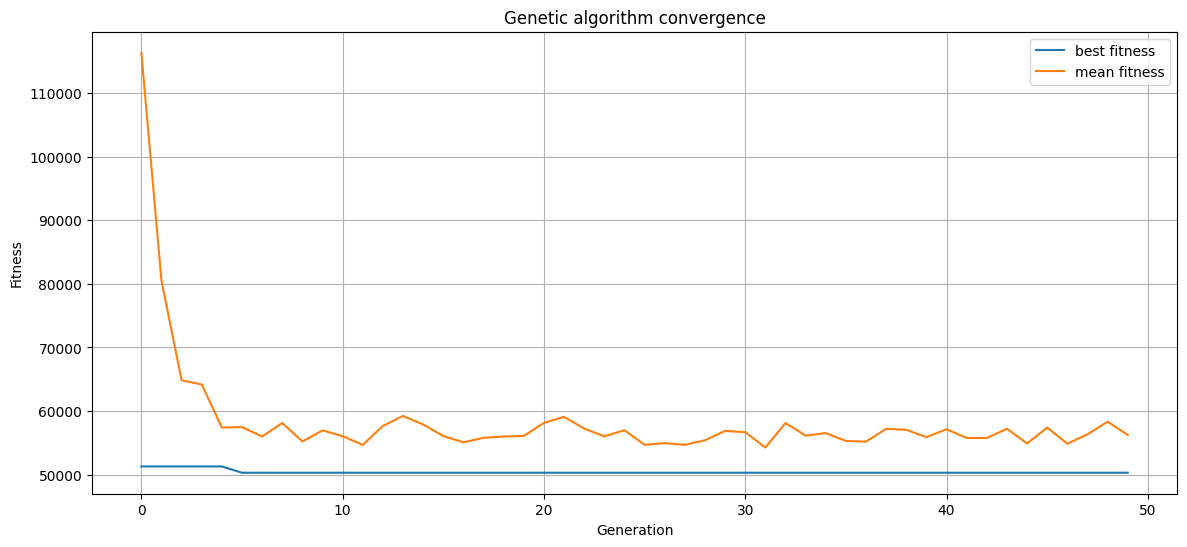

In [14]:
plt.figure(figsize=(14, 6))
plt.plot(ga_history_df["generation"], ga_history_df["best_fitness"], label="best fitness")
plt.plot(ga_history_df["generation"], ga_history_df["mean_fitness"], label="mean fitness")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title("Genetic algorithm convergence")
plt.legend()
plt.grid(True)
plt.show()

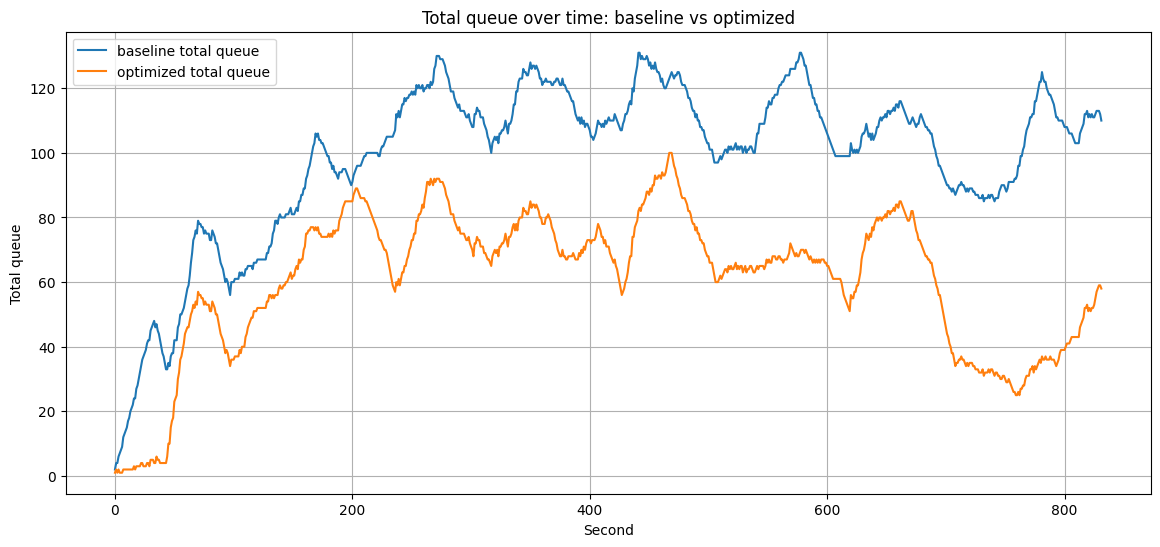

In [15]:
plt.figure(figsize=(14, 6))
plt.plot(baseline_sim_df["second"], baseline_sim_df["total_queue"], label="baseline total queue")
plt.plot(best_sim_df["second"], best_sim_df["total_queue"], label="optimized total queue")
plt.xlabel("Second")
plt.ylabel("Total queue")
plt.title("Total queue over time: baseline vs optimized")
plt.legend()
plt.grid(True)
plt.show()

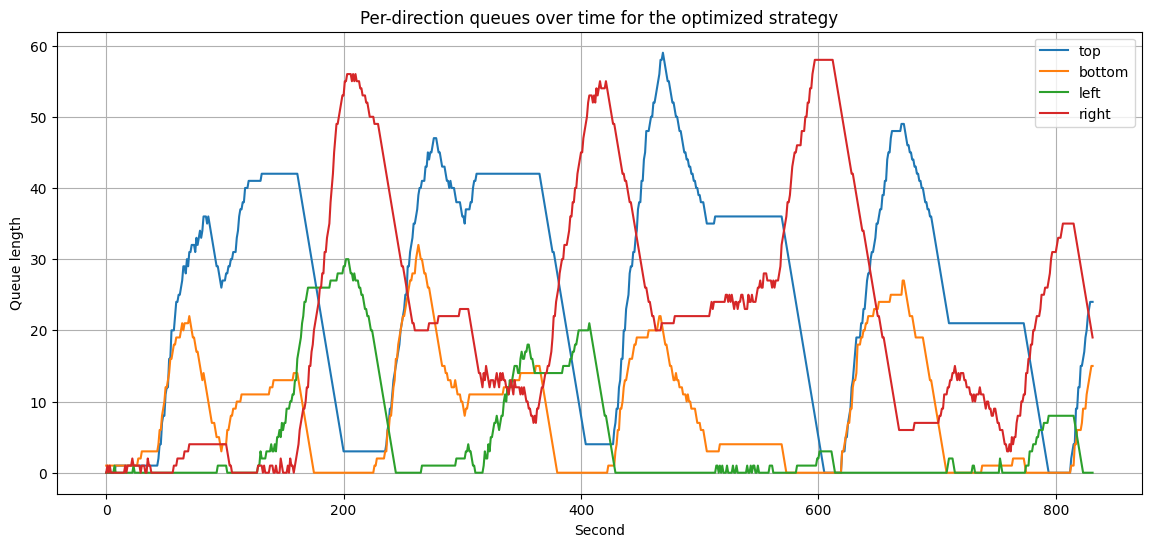

In [16]:
plt.figure(figsize=(14, 6))
plt.plot(best_sim_df["second"], best_sim_df["queue_top"], label="top")
plt.plot(best_sim_df["second"], best_sim_df["queue_bottom"], label="bottom")
plt.plot(best_sim_df["second"], best_sim_df["queue_left"], label="left")
plt.plot(best_sim_df["second"], best_sim_df["queue_right"], label="right")
plt.xlabel("Second")
plt.ylabel("Queue length")
plt.title("Per-direction queues over time for the optimized strategy")
plt.legend()
plt.grid(True)
plt.show()

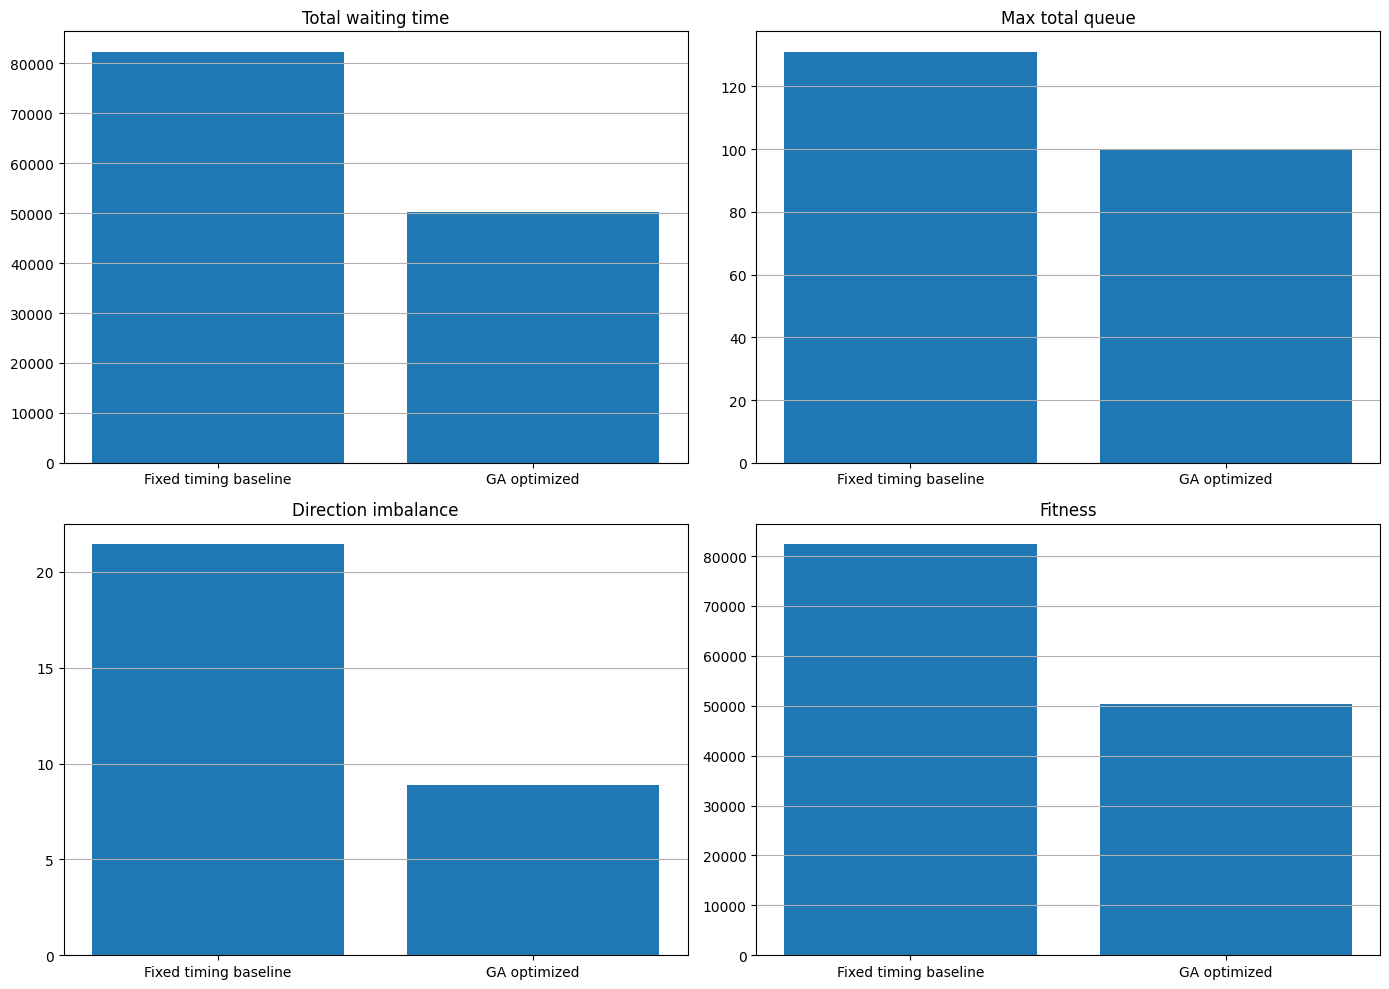

In [17]:
metrics_to_plot = [
    "Total waiting time",
    "Max total queue",
    "Direction imbalance",
    "Fitness"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, metric_name in zip(axes, metrics_to_plot):
    ax.bar(comparison_df["Strategy"], comparison_df[metric_name])
    ax.set_title(metric_name)
    ax.grid(True, axis="y")

plt.tight_layout()
plt.show()

In [19]:
best_settings_df = pd.DataFrame([{
    "green_vertical": best_chromosome["green_vertical"],
    "green_horizontal": best_chromosome["green_horizontal"],
    "yellow_time": best_chromosome["yellow_time"],
    "all_red_time": best_chromosome["all_red_time"],
    "phase_order_flag": best_chromosome["phase_order_flag"],
    "phase_order_description": "vertical first" if best_chromosome["phase_order_flag"] == 0 else "horizontal first"
}])

display(best_settings_df)
best_settings_df.to_csv(OUTPUT_DIR / "best_signal_settings.csv", index=False)

,green_vertical,green_horizontal,yellow_time,all_red_time,phase_order_flag,phase_order_description
0,39,57,2,0,1,horizontal first
